# Caderno 01: Análise Exploratória e Clivagens Sociais

Neste notebook, realizamos a Análise Exploratória de Dados (EDA) primária do dataset de respostas da Bússola Eleitoral.

## Referencial Teórico: Seymour Martin Lipset e Stein Rokkan (1967)
A teoria das **Clivagens Sociais** argumenta que o comportamento eleitoral é moldado por fraturas estruturais profundas na sociedade (ex: Centro vs Periferia, Estado vs Igreja, Capital vs Trabalho). Antes de olharmos para a opinião do indivíduo, precisamos olhar para as "caixas" demográficas em que ele está inserido. A demografia frequentemente antecede a ideologia.

Nossa análise focará em desvendar essas fraturas (Renda, Religião, Idade) dentro da nossa amostra.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações estéticas do Seaborn
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carregamento da Amostra Bruta


In [2]:
df = pd.read_csv('../data/raw/mock_voters.csv')
display(df.head())
print(f'Tamanho da amostra: {df.shape[0]} eleitores')

,idade,faixa_renda,religiao,bloco_d_estatais,bloco_d_tabelamento,bloco_e_punitivismo,bloco_e_educacao,bloco_g_corrupcao,bloco_g_pesquisa,bloco_g_politica_externa,rejeicao_absoluta
0,45-59,Mais de 10SM,Ateu/Agnostico,3,2,5,1,1,5,1,Nenhum
1,60+,Mais de 10SM,Outras,1,2,3,4,3,5,4,Flavio Bolsonaro
2,35-44,Mais de 10SM,Catolico,5,2,4,3,2,5,3,Flavio Bolsonaro
3,60+,Mais de 10SM,Outras,3,3,2,3,5,1,1,Ciro Gomes
4,60+,Mais de 10SM,Ateu/Agnostico,3,1,5,4,3,2,1,Flavio Bolsonaro


Tamanho da amostra: 1000 eleitores


## 2. Radiografia Demográfica
Analisamos a composição da nossa base. Desvios muito grandes em relação à sociedade real (excesso de jovens ou alta renda) exigirão ponderação estatística.


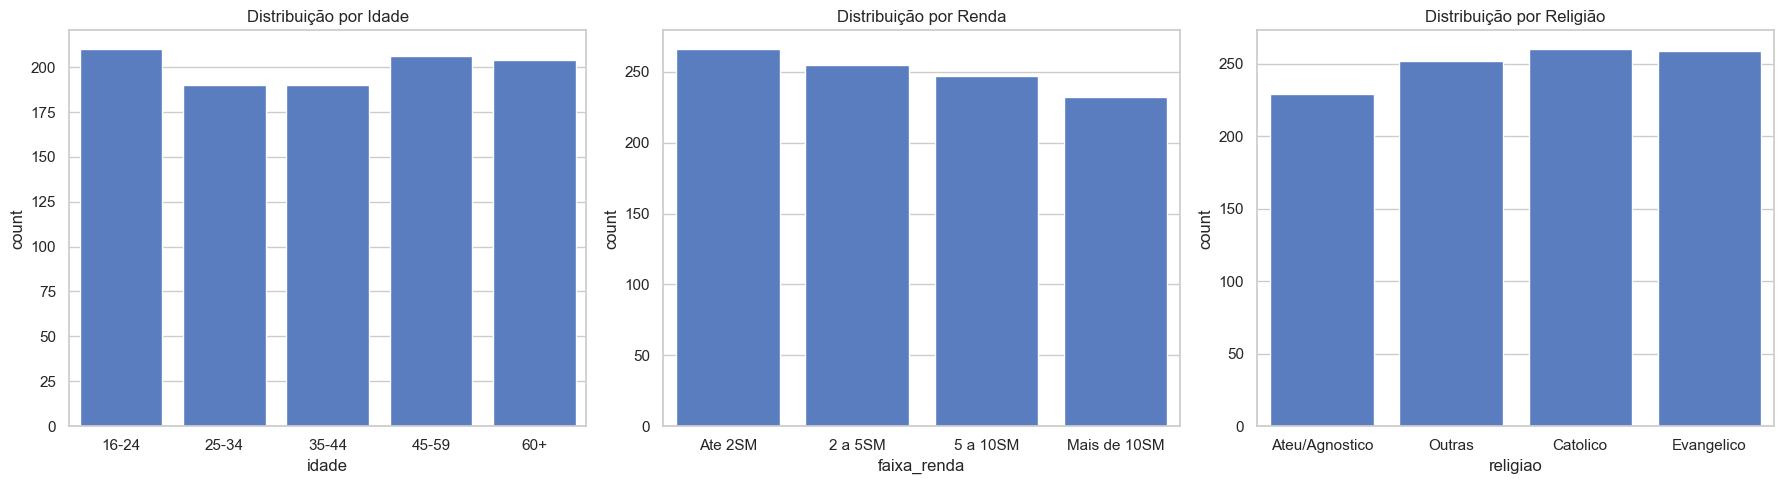

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='idade', order=['16-24', '25-34', '35-44', '45-59', '60+'], ax=axes[0])
axes[0].set_title('Distribuição por Idade')

sns.countplot(data=df, x='faixa_renda', order=['Ate 2SM', '2 a 5SM', '5 a 10SM', 'Mais de 10SM'], ax=axes[1])
axes[1].set_title('Distribuição por Renda')

sns.countplot(data=df, x='religiao', ax=axes[2])
axes[2].set_title('Distribuição por Religião')

plt.tight_layout()
plt.show()

## 3. Ponderação Amostral (Post-Stratification)
**Problema**: Pesquisas de internet (opt-in) possuem **viés de seleção**. Normalmente amostras online super-representam jovens escolarizados.

**Solução**: Atribuímos "pesos amostrais" a cada respondente. Se um jovem responde, seu peso será < 1; se um idoso de baixa escolaridade responde, seu peso será > 1, corrigindo matematicamente a pirâmide para que ela reflita os dados reais do TSE e IBGE.


In [4]:
# Exemplo simulado de cálculo de peso amostral baseado em idade.
# Supondo que a população real (TSE) seja 20% jovens (16-24), mas nossa amostra tem 30%.

amostra_idade = df['idade'].value_counts(normalize=True)
tse_idade = {'16-24': 0.15, '25-34': 0.20, '35-44': 0.25, '45-59': 0.25, '60+': 0.15}

pesos_idade = {k: tse_idade[k] / amostra_idade[k] for k in tse_idade.keys()}
df['peso_amostral'] = df['idade'].map(pesos_idade)
print('Pesos calculados por faixa etária:')
print(pesos_idade)

Pesos calculados por faixa etária:
{'16-24': np.float64(0.7142857142857143), '25-34': np.float64(1.0526315789473684), '35-44': np.float64(1.3157894736842106), '45-59': np.float64(1.2135922330097089), '60+': np.float64(0.7352941176470589)}
